SMS Spam Detection, Text Classification using Logistic Regression
Project Goal:
To create a machine learning model that automatically identifies whether an incoming SMS is spam (unwanted content) or a legitimate message (ham).

Data:
The dataset is located in the `data/sms_spam.csv` file. It is a classic collection of SMS messages labeled in English.

Techniques Used:
1.  EDA (Exploratory Data Analysis): Analyzing class balance and visualization (Pie Chart).
2.  NLP (Natural Language Processing): Text vectorization using the Bag-of-Words method (`TdidfVectorizer`).
3.  Modeling: Implementing Logistic Regression for binary classification.
4.  Evaluation: Assessing model performance using Accuracy Score on the test set.

Importing necessary libraries.

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

Reading csv file with data.

In [31]:
df = pd.read_csv("sms_spam.csv")
df.head()

,type,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


Replacing null values with "" strings.

In [32]:
df = df.where(pd.notnull(df), "")

In [33]:
print(df.shape)

(5574, 2)


Checking for null values.

In [34]:
print(df.isnull().sum())

type    0
text    0
dtype: int64


Creating pie chart with comparison of ham and spam count.

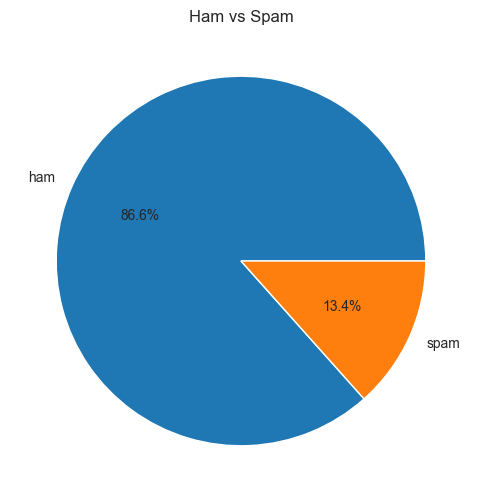

In [62]:
sns.set_style("whitegrid")
plt.figure(figsize=(6,6))
df["type"].value_counts().plot.pie(autopct="%.1f%%", labels=["ham", "spam"])
plt.ylabel('')
plt.title("Ham vs Spam")
plt.show()

Replacing "ham" and "spam" with 0/1.

In [35]:
df.loc[df["type"] == "ham", "type",] = 0
df.loc[df["type"] == "spam", "type",] = 1

Splitting data for X and Y.

In [36]:
X = df["text"]
Y = df["type"]

In [37]:
Y

0       0
1       0
2       1
3       0
4       0
       ..
5569    1
5570    0
5571    0
5572    0
5573    0
Name: type, Length: 5574, dtype: object

In [38]:
Y = Y.astype(int)

Splitting data for training and testing data.

In [39]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=10)

In [40]:
print(X.shape, X_train.shape, X_test.shape)

(5574,) (4459,) (1115,)


Text vectorization using TfidfVectorizer.

In [41]:
feature_extraction = TfidfVectorizer(min_df=1, stop_words='english', lowercase=True)
X_train_features = feature_extraction.fit_transform(X_train)
X_test_features = feature_extraction.transform(X_test)

In [42]:
print(X_test_features)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 7539 stored elements and shape (1115, 7492)>
  Coords	Values
  (0, 4753)	1.0
  (1, 2309)	0.2898759528406319
  (1, 3079)	0.24028301888659126
  (1, 3097)	0.2435310676233699
  (1, 3314)	0.2821506770246987
  (1, 3351)	0.4349790088999381
  (1, 3422)	0.45815145150856923
  (1, 3744)	0.2117880941375451
  (1, 4090)	0.2545555652752661
  (1, 4198)	0.33584608081052775
  (1, 6641)	0.3126736382018967
  (2, 1545)	0.5509747716863402
  (2, 2059)	0.40422364964587026
  (2, 3744)	0.3135198470226309
  (2, 4708)	0.6593446348876012
  (3, 1500)	0.5654473999439047
  (3, 4069)	0.48925450071696985
  (3, 4753)	0.41685995644252677
  (3, 7170)	0.516843349710143
  (4, 995)	0.6721003481129328
  (4, 2091)	0.6018375568777031
  (4, 3977)	0.4313614229366739
  (5, 856)	0.46260331375080604
  (5, 3078)	0.43135061961856597
  (5, 3827)	0.31793310560132315
  :	:
  (1109, 4090)	0.3256948438433364
  (1109, 4424)	0.5268919387280822
  (1110, 1912)	0.8248828889740921
  (

Implementing Logistic Regression for binary classification.

In [47]:
model = LogisticRegression()
model.fit(X_train_features, Y_train)
prediction_train = model.predict(X_train_features)

In [48]:
print(prediction_train.shape, Y_train.shape)

(4459,) (4459,)


Assessing training data accuracy.

In [50]:
accuracy_training = accuracy_score(Y_train, prediction_train)
print("Accuracy on training data: ", accuracy_training)

Accuracy on training data:  0.9703969499887867


In [51]:
prediction_test = model.predict(X_test_features)
print(prediction_test.shape, Y_test.shape)

(1115,) (1115,)


Assessing test data accuracy.

In [52]:
accuracy_test = accuracy_score(Y_test, prediction_test)
print("Accuracy on test data: ", accuracy_test)

Accuracy on test data:  0.9614349775784753
